# Markov State Model construction and analysis from pre-processed time series of a MD simulation of the HP35 protein.

Create new conda venv, install deeptime within it:


```{bash}

conda create -n MSM_env python=3.11
conda activate MSM_env
conda install -c conda-forge deeptime
conda install -c conda-forge matplotlib
conda install -c conda-forge pandas
conda deactivate
```

### Data import


- hp35.dihs: backbone dihedral angles [degrees]
- hp35.dihs.shifted: maximum-gap shifted backbone dihedral angles [rad]
- hp35.crystaldists: the atom distances of all contacts occurring in the crystal structure 2f4k [nm]
- hp35.mindists: all minimal distances occurring more frequently than 30% of the time [nm]
- hp35.mindists2: improved contact distances definition with all atom pairwise distances occurring more frequently than 30% of the time [nm]

In [ ]:
import numpy as np
import deeptime as deep
import matplotlib.pyplot as plt
import pandas as pd


from matplotlib.colors import ListedColormap
binary_cmap = ListedColormap(['white', 'black'])

data_folder = "../data/"

# Time series of the RMSD from the crystal structure

In [4]:
crystal_dis_array = np.loadtxt(data_folder + "hp35.crystaldists", delimiter = " ", dtype = float)

crystal_dis_array.shape # [nm] nanometers

(1526041, 53)

In [5]:
nframes = crystal_dis_array.shape[0]
simulation_length = 300 #microseconds
time_between_frames = simulation_length / nframes


print("Time between frames: (fs)", time_between_frames * 10**9)
# Is this the timestep of the original simulation? No, it cannot be. It is too large. Usually, the simulation step in all-atom simulation is around $~2 fs$. 
# Most likely, they saved the frames every X integration timesteps.
print("Probable frame storage rate:", 1/ (time_between_frames * 10**9 / 2))

Time between frames: (fs) 196587.1165977847
Probable frame storage rate: 1.0173606666666668e-05


In [4]:
RMSD_timeseries =np.sqrt(np.mean(crystal_dis_array**2, axis = 1)) * 10 # Armstrong

np.save("intermediate_outputs/RMSD_crystal_nm", RMSD_timeseries / 10)


time = np.arange(0, nframes) * time_between_frames
w = 10**4 # window size
MA_RMSD_timeseries = np.convolve(RMSD_timeseries, np.ones(w)/w, mode='same')

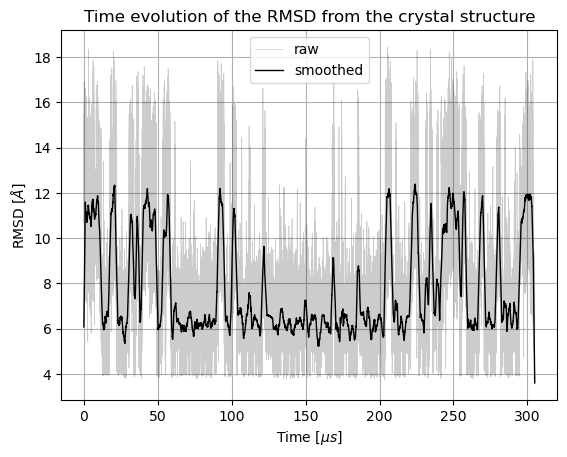

In [5]:
fig, ax = plt.subplots()
ax.plot(time, RMSD_timeseries, lw = 0.5, alpha = 0.2, color = "black", label = "raw")
ax.plot(time, MA_RMSD_timeseries, lw = 1, alpha = 1, color = "black", label = "smoothed")
ax.set_xlabel(r"Time [$\mu s$]")
ax.set_ylabel(r"RMSD [$Å$]")
ax.legend()
ax.grid()
ax.set_title("Time evolution of the RMSD from the crystal structure")
plt.show()

---
# Contacts

### MoSAIC clusters

In [6]:
MoSAIC_dict = {
    1 : [(3,14), (3, 13), (6,14), (5, 14)],
    2: [(7, 12), (7, 13), (6,12), (7,11), (6, 11), (6, 17)],
    3: [(12,17), (12,16), (12,20), (13, 17)],
    4: [(18,25), (17,25), (20, 25)],
    5: [(24, 28), (20, 28), (25, 29)],
    6: [(29,35), (29,34), (30,35), (29,33)],
    7: [(10,34), (9,32), (10,29)]
}

def cluster_idx(contact_tuple):
    idx = None
    for i in MoSAIC_dict.keys():
        if contact_tuple in MoSAIC_dict[i]:
            idx = i
            continue
    if idx == None:
        idx = 8
    return idx


from matplotlib import color_sequences
from matplotlib.colors import to_rgb



color_sequence = color_sequences['tab10']
MoSAIC_colors = {i: color_sequence[i-1] for i in range(1, 8)}
MoSAIC_colors[8] = "lightgray"

In [7]:
def MoSAIC_contact_map(contacts):
    n_res = 35
    contact_map_rgb = np.ones((n_res, n_res, 3))
    for contact in contacts:
        i, j = contact
        if 0 <= i < n_res and 0 <= j < n_res:
            color = to_rgb(MoSAIC_colors[cluster_idx(contact)])
            contact_map_rgb[i, j] = color
            contact_map_rgb[j, i] = color
    return contact_map_rgb

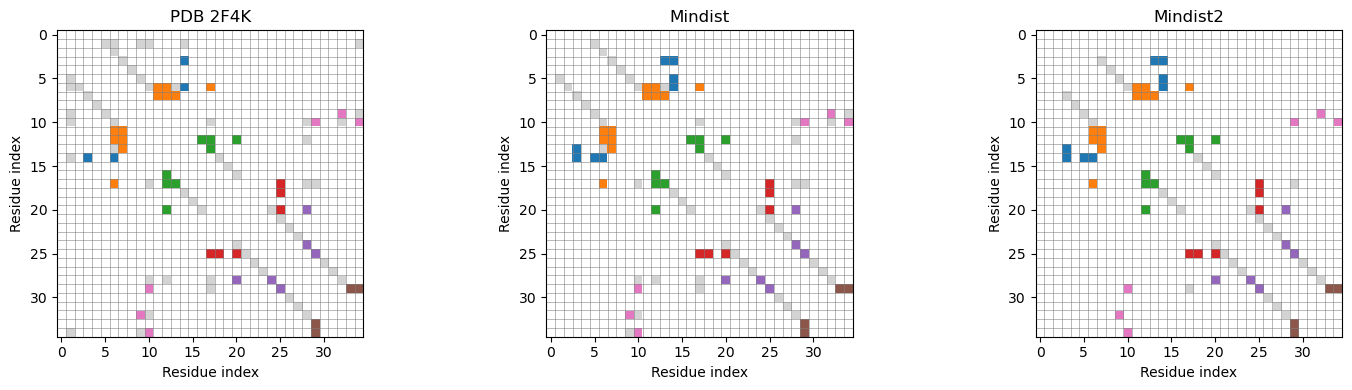

In [8]:
filenames = ["hp35.crystaldists.ndx", "hp35.mindists.ndx", "hp35.mindists2.ndx"]
titles = ["PDB 2F4K", "Mindist", "Mindist2"]
n_res = 35


fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i, name in enumerate(filenames):
    contacts = [
        tuple(x)
        for x in np.loadtxt(
            data_folder + name,
            comments="#",
            usecols=(0, 1),
            dtype=int
        )
    ]
    ax = axs[i]
    ax.imshow(MoSAIC_contact_map(contacts), origin="upper")
    ax.set_xticks(np.arange(-0.5, n_res, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_res, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlim(-0.5, n_res - 0.5)
    ax.set_ylim(n_res - 0.5, -0.5)
    ax.set_xlabel("Residue index")
    ax.set_ylabel("Residue index")
    ax.set_title(titles[i])
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Timeseries of mindists2 contacts

In [9]:
mindists2_array = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float) * 10 # armstrong
mindists2_array.shape

(1526041, 42)

In [10]:
# two residues are considered in contact if the min. distance between non-hydrogen atoms is less than 4.5 Å = 0.45 nm.
# Q is defined as the fraction of native contacts

subsets = ['all', 'MoSAIC1', 'MoSAIC2', 'MoSAIC3', 'MoSAIC4', 'MoSAIC5', 'MoSAIC6', 'MoSAIC7', 'MoSAIC8']

column_subsects = {
    'all': list(range(mindists2_array.shape[1])),
    'MoSAIC1': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 1],
    'MoSAIC2': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 2],
    'MoSAIC3': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 3],
    'MoSAIC4': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 4],
    'MoSAIC5': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 5],
    'MoSAIC6': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 6],
    'MoSAIC7': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 7],
    'MoSAIC8': [i for i, contact in enumerate(contacts) if cluster_idx(contact) == 8]
}

for subset in subsets:
    column_indices = column_subsects[subset]
    subset_mindists2_array = mindists2_array[:, column_indices]

    total_cluster_distance_timeseries = np.sum(subset_mindists2_array, axis = 1)
    np.save(f"intermediate_outputs/totdist_timeseries_{subset}.npy", total_cluster_distance_timeseries)


    binary_contact_timeseries = np.where(subset_mindists2_array < 4.5, 1, 0) 
    Q_timeseries = np.sum(binary_contact_timeseries, axis = 1) / subset_mindists2_array.shape[1]
    MA_Q_timeseries = np.convolve(Q_timeseries, np.ones(w)/w, mode='same')
    np.save(f"intermediate_outputs/Q_timeseries_{subset}.npy", Q_timeseries)

In [11]:
fig, ax = plt.subplots()
ax.plot(time, 1 - Q_timeseries, lw = 0.5, alpha = 0.2, color = "black", label = "raw")
ax.plot(time, 1 - MA_Q_timeseries, lw = 1, alpha = 1, color = "black", label = "smoothed")
ax.set_xlabel(r"Time [$\mu s$]")
ax.set_ylabel(r"1 - Q")
ax.legend()
ax.grid()
ax.set_title("Time evolution of the fraction of native contacts")
plt.show()

KeyboardInterrupt: 

---
## Dihedrals 

Phi: $\Phi$
Psi: $\Psi$

In [ ]:
dihedral_names = np.loadtxt(data_folder + "hp35.dihs.names", comments = ["#", "\n"], dtype = str)

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_6574/3719376941.py:1: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  dihedral_names = np.loadtxt(data_folder + "hp35.dihs.names", comments = ["#", "\n"], dtype = str)


In [ ]:
print(len(dihedral_names)/2)

33.0


In [ ]:
dihedral_timeseries = np.loadtxt(data_folder + "hp35.dihs", delimiter = " ", dtype = float)
phis_timeseries = dihedral_timeseries[:, 0::2] # degrees
psis_timeseries = dihedral_timeseries[:, 1::2] # degrees
print(dihedral_timeseries.shape)

(1526041, 66)


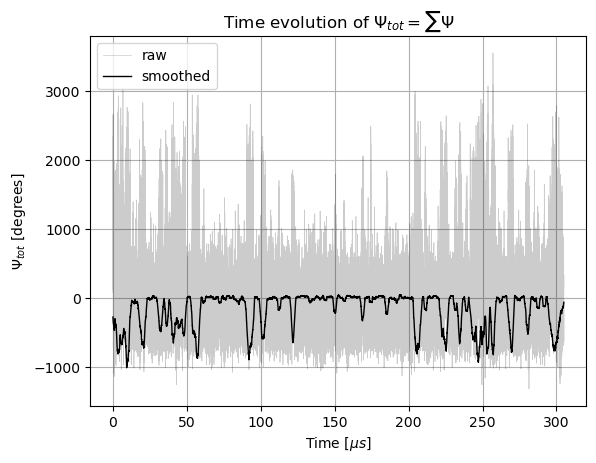

In [ ]:
total_psi_timeseries = np.sum(psis_timeseries, axis = 1)
MA_total_psi_timeseries = np.convolve(total_psi_timeseries, np.ones(w)/w, mode='same')

fig, ax = plt.subplots()
ax.plot(time, total_psi_timeseries, lw = 0.5, alpha = 0.2, color = "black", label = "raw")
ax.plot(time, 1 - MA_total_psi_timeseries, lw = 1, alpha = 1, color = "black", label = "smoothed")
ax.set_xlabel(r"Time [$\mu s$]")
ax.set_ylabel(r"$\Psi_{tot}$ [degrees]")
ax.legend()
ax.grid()
ax.set_title(r"Time evolution of $\Psi_{tot} = \sum \Psi$")
plt.show()

In [ ]:
dihedral_timeseries = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
dihedral_timeseries.shape

(1526041, 66)